# E-Commerce Customer Analytics

## Multivariate Analysis

This notebook extends the exploratory analysis across four e-commerce datasets using correlation heatmaps, grouped comparisons, bubble plots, Principal Component Analysis (PCA), and simple linear regression.

The goal is to identify multivariate structure, evaluate whether the datasets can be summarized in fewer dimensions, and assess which relationships are useful for later modeling. Results are interpreted as associations rather than causal effects.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("../data")


## 1. User Behavior & Engagement

This section examines multivariate relationships among sales, engagement, and add-to-cart behavior.


### 1.1 Data Setup


In [2]:
df_behavior = pd.read_pickle(DATA_DIR / "df_behavior_eda.pkl")
df_behavior.shape


(51207, 27)

### 1.2 Variable Selection

The analysis focuses on financial, browsing, engagement, and purchase-intent variables. `Add to Cart` is treated as a target-like variable for interpretation and is excluded from the PCA inputs.


In [3]:
numeric_cols_behavior = ["Age", "Sales", "Quantity", "Discount", "Profit","Shipping Cost", "Browsing Time (min)", "Like","Share", "Add to Cart"]

categorical_cols_behavior = ["Segment", "Region", "Gender", "Education","Marital Status", "Ship Mode", "Product Category", "Order Priority"]

time_col_behavior = "Order Date"


### 1.3 Correlation and Grouped Heatmaps

Correlation and grouped heatmaps are used to compare numeric relationships and category-level differences in purchase intent and profitability.


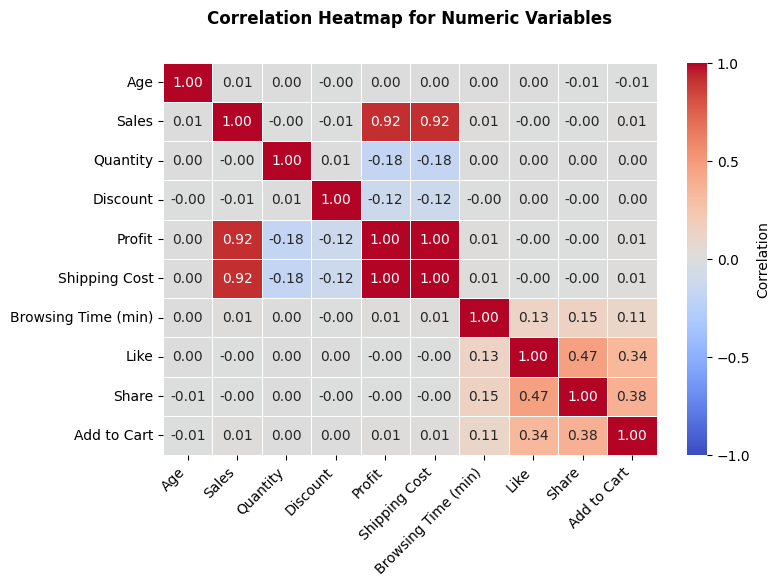

In [4]:
# Correlation heatmap for numeric variables

corr_behavior = df_behavior[numeric_cols_behavior].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_behavior,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0, cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Heatmap for Numeric Variables", fontweight="bold", pad=14, y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

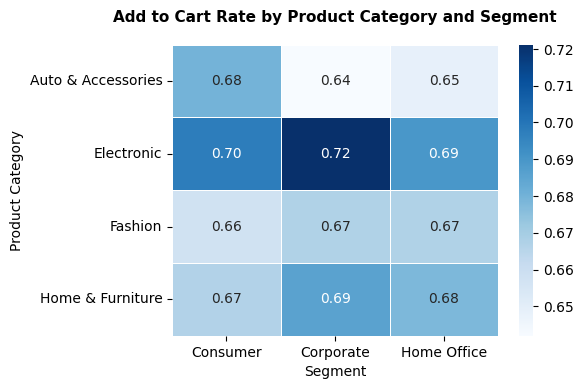

In [5]:
# Add to Cart rate heatmap by Product Category and Segment

add_to_cart_heatmap = df_behavior.pivot_table(index="Product Category", columns="Segment", values="Add to Cart",aggfunc="mean")

plt.figure(figsize=(6, 4))
sns.heatmap(add_to_cart_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5)

plt.title("Add to Cart Rate by Product Category and Segment", y=1.05, fontweight="bold", fontsize=11)
plt.xlabel("Segment")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Add-to-cart rates are fairly similar across most product categories and customer segments. Electronic products show the highest rates, especially in the Corporate segment, but the differences are not large enough to explain purchase intent on their own.


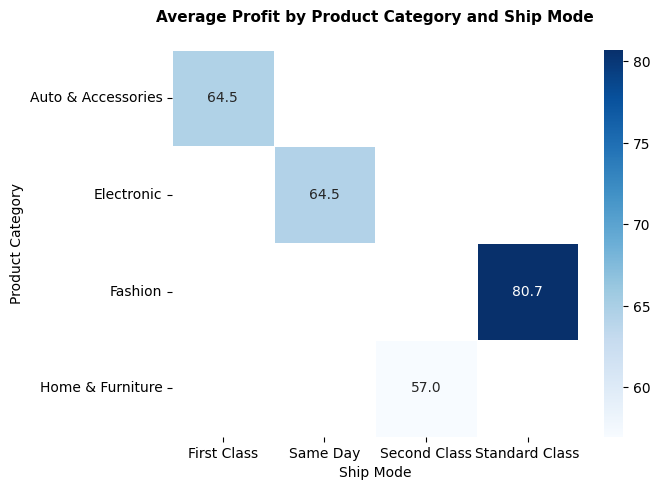

In [6]:
profit_heatmap = df_behavior.pivot_table(index="Product Category",columns="Ship Mode",values="Profit",aggfunc="mean")

plt.figure(figsize=(7, 5))
sns.heatmap(profit_heatmap,annot=True,cmap="Blues",fmt=".1f",linewidths=0.5)

plt.title("Average Profit by Product Category and Ship Mode", y=1.05, fontweight="bold", fontsize=11, x=0.5)
plt.xlabel("Ship Mode")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

The profit heatmap is sparse because many product-category and shipping-mode combinations do not occur in the data. These averages should therefore be interpreted cautiously.


### 1.4 Bubble Plot Analysis

The bubble plot compares average browsing time, add-to-cart rate, and average sales across product categories.


In [7]:
bubble_behavior = (df_behavior.groupby("Product Category").agg(
        avg_browsing_time=("Browsing Time (min)", "mean"),
        add_to_cart_rate=("Add to Cart", "mean"),
        avg_sales=("Sales", "mean")).reset_index())

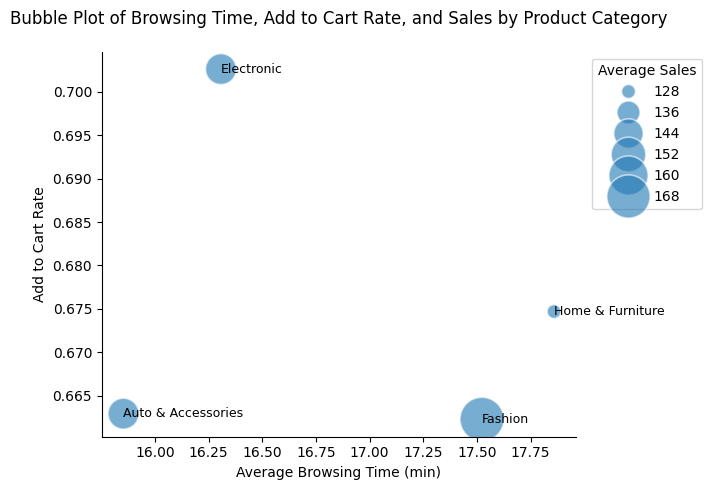

In [8]:
# Bubble plot: Browsing Time, Add to Cart Rate, and Sales

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=bubble_behavior,x="avg_browsing_time",y="add_to_cart_rate",size="avg_sales",sizes=(100, 1000),alpha=0.6,legend="brief")

for i, row in bubble_behavior.iterrows():
    ax.text(
        row["avg_browsing_time"],
        row["add_to_cart_rate"],
        row["Product Category"],
        ha="left",
        va="center",
        fontsize=9)

plt.title("Bubble Plot of Browsing Time, Add to Cart Rate, and Sales by Product Category", y=1.05, fontsize=12)
plt.xlabel("Average Browsing Time (min)")
plt.ylabel("Add to Cart Rate")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(title="Average Sales", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Electronic has the highest add-to-cart rate, while Fashion and Home & Furniture show longer average browsing times. Longer browsing time therefore does not translate directly into stronger purchase intent. Average sales also do not perfectly align with add-to-cart rates.


### 1.5 Principal Component Analysis

PCA is applied to scaled numeric features to assess whether the dataset can be represented with fewer dimensions. `Add to Cart` is kept outside the PCA inputs and used only for interpretation.


In [9]:
pca_cols_behavior = ["Age", "Sales", "Quantity", "Discount", "Profit","Shipping Cost", "Browsing Time (min)", "Like", "Share"]

X_pca_behavior = df_behavior[pca_cols_behavior].copy()
y_pca_behavior = df_behavior["Add to Cart"].copy()


In [10]:
# Scale the PCA data
scaler = StandardScaler()
X_pca_scaled_behavior  = scaler.fit_transform(X_pca_behavior)

In [11]:
# run PCA on the scaled data
pca_behavior = PCA()
pca_results_behavior = pca_behavior.fit_transform(X_pca_scaled_behavior )

In [12]:
# Explained variance table
explained_variance_behavior = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca_cols_behavior))],
    "Explained Variance Ratio": pca_behavior.explained_variance_ratio_,
    "Cumulative Explained Variance": pca_behavior.explained_variance_ratio_.cumsum()
})

explained_variance_behavior

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.325412,0.325412
1,PC2,0.171102,0.496515
2,PC3,0.111619,0.608134
3,PC4,0.111280,0.719414
4,PC5,0.110244,0.829658
5,PC6,0.103053,0.932710
6,PC7,0.059097,0.991807
7,PC8,0.008191,0.999998
8,PC9,0.000002,1.000000


In [13]:
# Create PCA loadings table

pca_loadings_behavior = pd.DataFrame(pca_behavior.components_.T,index=pca_cols_behavior,columns=[f"PC{i+1}" for i in range(len(pca_cols_behavior))])

pca_loadings_behavior.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Age,0.004,-0.008,-0.154,0.899,0.410,-0.019,0.012,-0.001,0.000
Sales,0.555,0.001,0.216,0.045,-0.022,-0.014,0.001,0.801,-0.001
Quantity,-0.107,0.009,0.699,0.380,-0.572,-0.072,0.000,-0.152,-0.000
Discount,-0.074,0.001,0.664,-0.207,0.706,0.050,0.007,-0.096,-0.000
Profit,0.581,-0.000,0.004,-0.003,0.002,-0.005,0.001,-0.402,0.708
Shipping Cost,0.581,-0.000,0.003,-0.003,0.002,-0.004,0.001,-0.404,-0.707
Browsing Time (min),0.009,0.343,0.013,0.054,-0.062,0.935,-0.025,0.001,0.000
Like,-0.001,0.662,-0.008,-0.005,0.030,-0.259,-0.703,-0.000,-0.000
Share,-0.002,0.667,-0.012,-0.016,0.014,-0.224,0.711,0.001,0.000


PC1 is dominated by `Sales`, `Profit`, and `Shipping Cost`, representing a financial/order-value direction. PC2 is driven mainly by `Like` and `Share`, with some contribution from browsing time, representing an engagement direction.


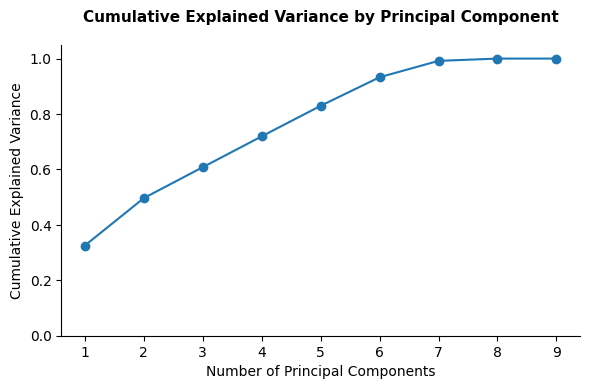

In [14]:
# Plot cumulative explained variance

plt.figure(figsize=(6, 4))

plt.plot(range(1, len(pca_behavior.explained_variance_ratio_) + 1),pca_behavior.explained_variance_ratio_.cumsum(),marker="o")

plt.title("Cumulative Explained Variance by Principal Component", y=1.05,fontsize=11, fontweight="bold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(pca_behavior.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

PC1 explains about 32.5% of total variance, while PC1 and PC2 together explain about 49.7%. Five components are needed to reach roughly 83%, so one or two components are not sufficient to represent the full dataset.


In [15]:
pca_scores_behavior = pd.DataFrame(pca_results_behavior[:, :2],columns=["PC1", "PC2"],index=X_pca_behavior.index)

pca_scores_behavior["Add to Cart"] = y_pca_behavior.loc[X_pca_behavior.index]


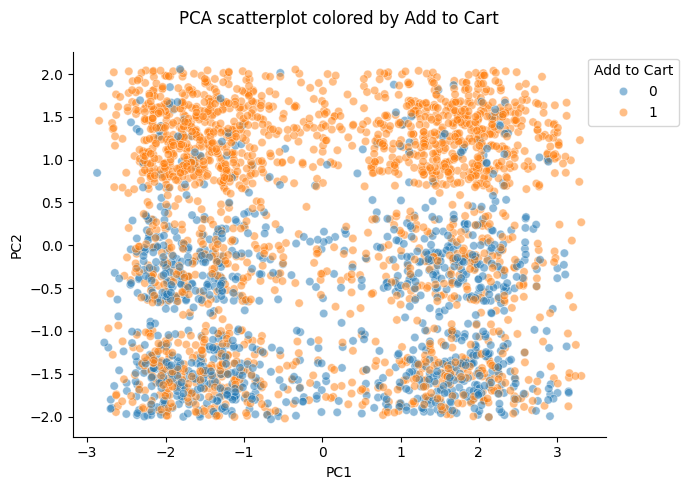

In [16]:
# PCA scatterplot using PC1 and PC2

pca_sample_behavior = pca_scores_behavior.sample(3000, random_state=42)

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=pca_sample_behavior,x="PC1", y="PC2",hue="Add to Cart",alpha=0.5)

plt.title("PCA scatterplot colored by Add to Cart", y=1.05, fontsize=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(title="Add to Cart", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

The first two components show some separation in add-to-cart behavior, particularly along PC2, but the two groups still overlap substantially. PCA therefore captures useful structure without cleanly separating purchase intent.


### 1.6 Linear Regression Analysis

Simple linear regressions are used to evaluate the strongest numeric relationships identified in the correlation analysis.


In [17]:
# Linear regression using the strongest correlated numeric variables

variables_behavior = ["Sales", "Profit", "Shipping Cost"]

results_behavior = []

for target in variables_behavior:
    
    predictors = [col for col in variables_behavior if col != target]
    
    X = df_behavior[predictors]
    y = df_behavior[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_behavior.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse
    })

regression_results_behavior = pd.DataFrame(results_behavior)
regression_results_behavior

,target,predictors,test_r2_score,test_mse
0,Sales,"[Profit, Shipping Cost]",0.847255,662.690655
1,Profit,"[Sales, Shipping Cost]",0.999964,0.086250
2,Shipping Cost,"[Sales, Profit]",0.999964,0.000864


`Profit` and `Shipping Cost` are predicted almost perfectly from the other financial variables, while predicting `Sales` produces a test R² of about 0.85. The near-perfect relationship between `Profit` and `Shipping Cost` suggests substantial redundancy, so these results should not be interpreted as independent predictive signals.


### 1.7 Dataset 1 Summary

Dataset 1 shows clear multivariate structure in its financial variables and weaker but visible engagement structure. PCA separates financial and engagement directions, but two components explain only about half of the total variance. Add-to-cart behavior shows some association with product category and engagement, although no single variable or low-dimensional PCA view fully explains purchase intent.


## 2. Sales & Customer Insights

This section evaluates whether the dataset contains meaningful multivariate structure related to customer value and churn probability.


### 2.1 Data Setup


In [18]:
df_sales = pd.read_pickle(DATA_DIR / "df_sales_eda.pkl")
df_sales.shape


(10000, 15)

### 2.2 Variable Selection

`Churn_Probability` is treated as the main target-like variable and is excluded from PCA inputs.


In [19]:
numeric_cols_sales = ["Purchase_Frequency", "Average_Order_Value","Time_Between_Purchases", "Churn_Probability","Lifetime_Value"]

categorical_cols_sales = ["Most_Frequent_Category", "Region", "Season","Preferred_Purchase_Times", "Retention_Strategy"]

date_cols_sales = ["Launch_Date", "Peak_Sales_Date"]
target_like_sales = "Churn_Probability"

pca_input_cols_sales = [col for col in numeric_cols_sales if col != target_like_sales]


### 2.3 Correlation and Grouped Heatmaps

The numeric correlation matrix and grouped churn-probability heatmap are used to look for relationships across customer-value and retention variables.


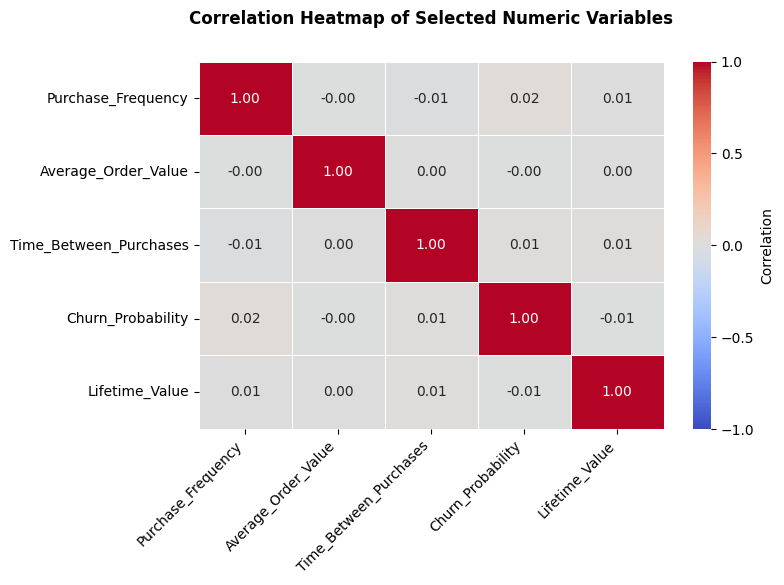

In [20]:
corr_sales = df_sales[numeric_cols_sales].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_sales,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]}
)

plt.title("Correlation Heatmap of Selected Numeric Variables",fontweight="bold",pad=14,y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


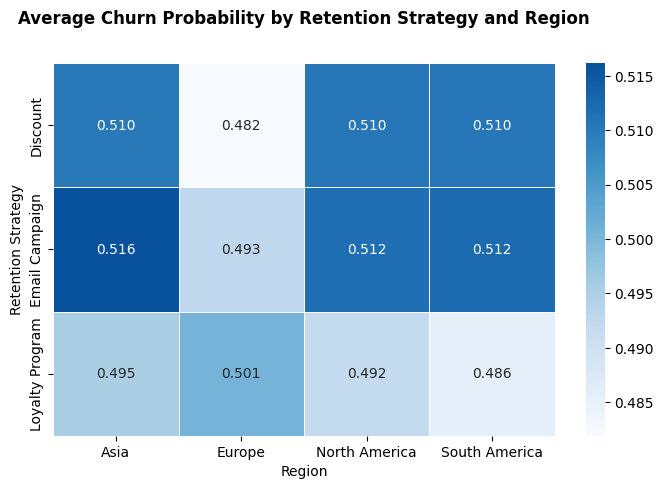

In [21]:
churn_grouped_heatmap = df_sales.pivot_table(index="Retention_Strategy",columns="Region",values="Churn_Probability",aggfunc="mean")

plt.figure(figsize=(7, 5))
sns.heatmap(churn_grouped_heatmap,annot=True,cmap="Blues",center=df_sales["Churn_Probability"].mean(),fmt=".3f",linewidths=0.5)

plt.title("Average Churn Probability by Retention Strategy and Region",fontsize=12,fontweight="bold",pad=15,y=1.05)
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.ylabel("Retention Strategy")
plt.tight_layout()
plt.show()


The selected numeric variables have correlations close to zero. Average churn probability also remains near 0.50 across retention strategies and regions, with only small group differences. These results provide little evidence of meaningful multivariate structure.


### 2.4 Bubble Plot Analysis

The bubble plot compares average order value, churn probability, and lifetime value across product categories.


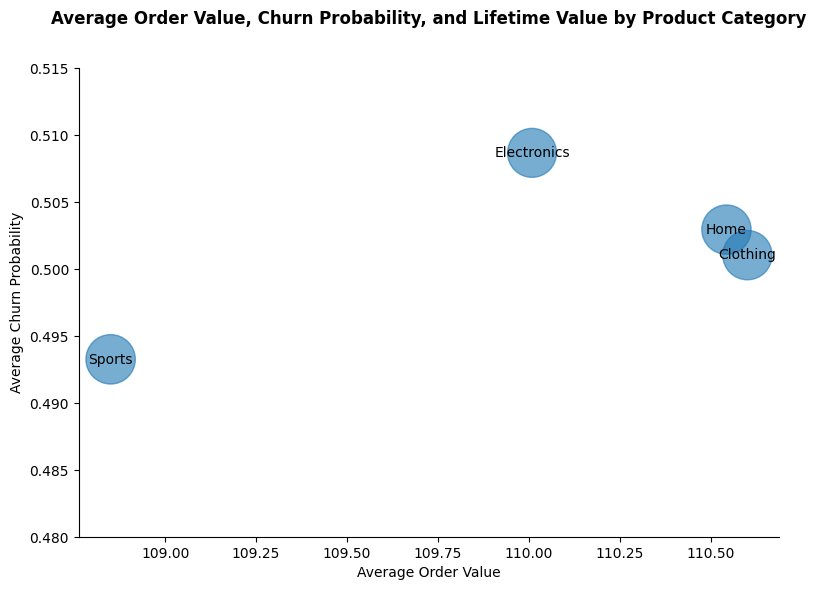

,Most_Frequent_Category,avg_order_value,avg_churn_probability,avg_lifetime_value
0,Clothing,110.600653,0.501024,5047.698829
1,Electronics,110.008543,0.508660,4973.470783
2,Home,110.543069,0.502928,5041.930477
3,Sports,108.850025,0.493245,5066.964548


In [22]:
# Simple bubble plot by product category

bubble_sales = (df_sales.groupby("Most_Frequent_Category").agg(
                                                            avg_order_value=("Average_Order_Value", "mean"),
                                                            avg_churn_probability=("Churn_Probability", "mean"),
                                                            avg_lifetime_value=("Lifetime_Value", "mean")).reset_index())

plt.figure(figsize=(8, 6))
plt.scatter(bubble_sales["avg_order_value"],bubble_sales["avg_churn_probability"],s=bubble_sales["avg_lifetime_value"] / 4,alpha=0.6)

# Add category labels
for i, row in bubble_sales.iterrows():
    plt.text(row["avg_order_value"],row["avg_churn_probability"], row["Most_Frequent_Category"],fontsize=10,ha="center",va="center")

plt.title("Average Order Value, Churn Probability, and Lifetime Value by Product Category",fontsize=12,fontweight="bold",pad=15, y=1.05)
plt.xlabel("Average Order Value")
plt.ylabel("Average Churn Probability")
plt.ylim(0.48, 0.515)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

bubble_sales


Product categories cluster closely together: average order value, churn probability, and lifetime value are all very similar across groups. Product category therefore provides little separation in this dataset.


### 2.5 Principal Component Analysis

PCA is used to test whether the numeric features can be summarized by a smaller number of dimensions.


In [23]:
# Select PCA input columns
pca_input_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Lifetime_Value"]

# Scale PCA input features
scaler = StandardScaler()
X_sales_scaled = scaler.fit_transform(df_sales[pca_input_cols_sales])

# Run PCA
pca_sales = PCA()
X_sales_pca = pca_sales.fit_transform(X_sales_scaled)

# Explained variance table
explained_variance_sales = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca_input_cols_sales))],
    "Explained Variance Ratio": pca_sales.explained_variance_ratio_,
    "Cumulative Explained Variance": pca_sales.explained_variance_ratio_.cumsum()
})

explained_variance_sales


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.253354,0.253354
1,PC2,0.251751,0.505104
2,PC3,0.249300,0.754405
3,PC4,0.245595,1.000000


In [24]:
# PCA loadings table
pca_loadings_sales = pd.DataFrame(pca_sales.components_.T,columns=[f"PC{i+1}" for i in range(len(pca_input_cols_sales))],index=pca_input_cols_sales)

pca_loadings_sales.round(3)

,PC1,PC2,PC3,PC4
Purchase_Frequency,-0.154,0.828,-0.014,0.539
Average_Order_Value,0.408,0.101,0.907,-0.016
Time_Between_Purchases,0.687,-0.277,-0.268,0.616
Lifetime_Value,0.581,0.477,-0.324,-0.575


Explained variance is spread almost evenly across the four components. PC1 explains about 25.3%, and PC1 plus PC2 explain about 50.5%, indicating no dominant low-dimensional structure.


In [25]:
pca_scores_sales = pd.DataFrame(X_sales_pca[:, :2],columns=["PC1", "PC2"])
pca_scores_sales["Churn_Probability"] = df_sales["Churn_Probability"].values


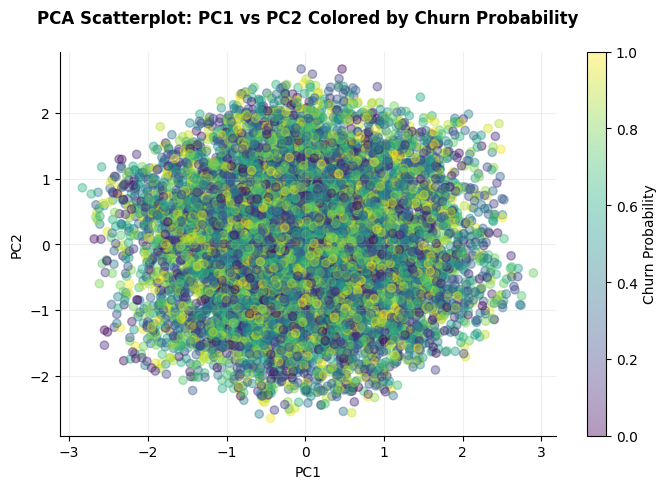

In [26]:
# PCA scatterplot: PC1 vs PC2 colored by churn probability
plt.figure(figsize=(7, 5))

scatter = plt.scatter(pca_scores_sales["PC1"],pca_scores_sales["PC2"],c=pca_scores_sales["Churn_Probability"],alpha=0.4)

plt.colorbar(scatter, label="Churn Probability")
plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Churn Probability",y=1.02,fontsize=12,fontweight="bold",pad=15)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The PCA scatterplot shows no clear clusters or separation by `Churn_Probability`. Low and high churn-probability values remain mixed throughout the first two components.


### 2.6 Linear Regression Analysis

Linear regression is used as an additional check of whether the selected numeric variables contain useful predictive relationships.


In [27]:
regression_targets_sales = ["Churn_Probability","Lifetime_Value","Average_Order_Value"]

regression_results_sales = []

for target in regression_targets_sales:
    
    predictors = [col for col in numeric_cols_sales if col != target]
    
    X = df_sales[predictors]
    y = df_sales[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    regression_results_sales.append({
        "Target": target,
        "Predictors": ", ".join(predictors),
        "Test R2": r2,
        "Test MSE": mse
    })

regression_results_sales = pd.DataFrame(regression_results_sales)

regression_results_sales

,Target,Predictors,Test R2,Test MSE
0,Churn_Probability,"Purchase_Frequency, Average_Order_Value, Time_...",-0.002402,8.242790e-02
1,Lifetime_Value,"Purchase_Frequency, Average_Order_Value, Time_...",-0.001158,7.917642e+06
2,Average_Order_Value,"Purchase_Frequency, Time_Between_Purchases, Ch...",-0.002390,2.750367e+03


All tested models have negative test R² values, meaning they perform worse than a mean-value baseline on the holdout data. This is consistent with the near-zero correlations and lack of PCA separation.


### 2.7 Dataset 2 Summary

Dataset 2 is technically clean but provides very limited analytical and predictive signal. Numeric relationships are near zero, grouped churn probabilities are nearly uniform, PCA variance is distributed evenly, and the tested regressions have negative test R² values.

This unusually weak structure may be consistent with a simplified or synthetic-like dataset, but that cannot be established from the analysis alone. For the broader portfolio project, this dataset is therefore treated as lower-value evidence and is deprioritized for downstream modeling.


## 3. Customer Churn

This section examines multivariate relationships associated with churn, customer activity, complaints, tenure, and order behavior.


### 3.1 Data Setup


In [28]:
df_churn = pd.read_pickle(DATA_DIR / "df_churn_eda.pkl")
df_churn.shape


(5630, 20)

### 3.2 Variable Selection

`Churn` is the target variable. It is included in correlation and grouped analyses for interpretation but excluded from PCA inputs.


In [29]:
numeric_cols_churn = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "NumberOfDeviceRegistered", "SatisfactionScore",
    "NumberOfAddress", "Complain",
    "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder",
    "CashbackAmount", "Churn"
]

pca_input_cols_churn = [col for col in numeric_cols_churn if col != "Churn"]

categorical_cols_churn = ["PreferredLoginDevice", "PreferredPaymentMode","Gender", "PreferedOrderCat", "MaritalStatus"]

target_col_churn = "Churn"

missing_selected_churn = (df_churn[numeric_cols_churn].isna().sum().sort_values(ascending=False))

missing_selected_churn[missing_selected_churn > 0]


DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64

Several numeric predictors still contain missing values because the EDA version intentionally preserves them. Pairwise correlations can use the available observations, while PCA and regression use temporary median-imputed copies without changing the original dataframe.


### 3.3 Correlation and Grouped Heatmaps

Correlation and grouped heatmaps are used to identify multivariate patterns associated with churn.


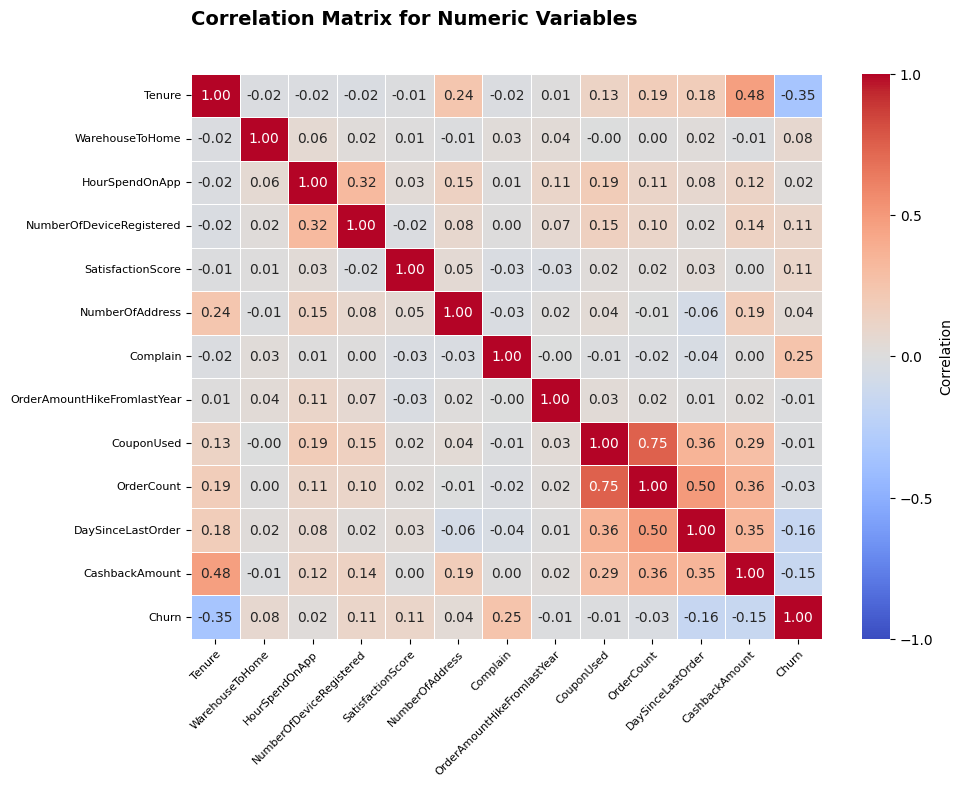

In [30]:
# Correlation heatmap for numeric variables

corr_churn = df_churn[numeric_cols_churn].corr()

# Heatmap of correlations

plt.figure(figsize=(10, 8))

ax = sns.heatmap(corr_churn,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

In [31]:
print("Correlations with Churn:")
display(corr_churn["Churn"].drop("Churn").sort_values(key=abs, ascending=False))

print("\nStrongest numeric correlations:")
corr_pairs = corr_churn.unstack().reset_index()
corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
corr_pairs = corr_pairs[corr_pairs["Variable_1"] < corr_pairs["Variable_2"]]
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()
display(corr_pairs.sort_values("Abs_Correlation", ascending=False).head(10))

Correlations with Churn:


Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
Name: Churn, dtype: float64


Strongest numeric correlations:


,Variable_1,Variable_2,Correlation,Abs_Correlation
113,CouponUsed,OrderCount,0.745245,0.745245
139,DaySinceLastOrder,OrderCount,0.497928,0.497928
143,CashbackAmount,Tenure,0.476380,0.476380
152,CashbackAmount,OrderCount,0.360984,0.360984
114,CouponUsed,DaySinceLastOrder,0.358930,0.358930
156,Churn,Tenure,-0.349408,0.349408
153,CashbackAmount,DaySinceLastOrder,0.347172,0.347172
29,HourSpendOnApp,NumberOfDeviceRegistered,0.316800,0.316800
151,CashbackAmount,CouponUsed,0.286728,0.286728
162,Churn,Complain,0.250188,0.250188


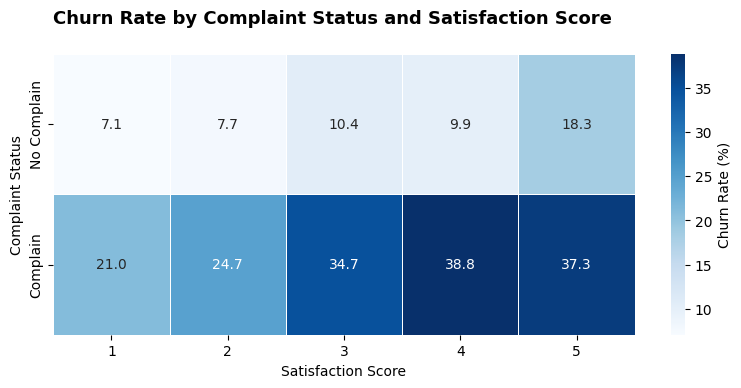

In [32]:
# Grouped heatmap for churn rate by Complain and SatisfactionScore

churn_group_heatmap = df_churn.pivot_table(values="Churn",index="Complain",columns="SatisfactionScore",aggfunc="mean") * 100

churn_group_heatmap.index = churn_group_heatmap.index.map({0: "No Complain", 1: "Complain"})

plt.figure(figsize=(8, 4))

ax = sns.heatmap(churn_group_heatmap,annot=True,fmt=".1f",cmap="Blues",linewidths=0.5,cbar_kws={"label": "Churn Rate (%)"})

ax.set_title("Churn Rate by Complaint Status and Satisfaction Score", loc="left", fontsize=13, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Complaint Status")

plt.tight_layout()
plt.show()

Complaint status shows a clear association with churn: customers with complaints have substantially higher churn rates across satisfaction-score groups. Satisfaction score alone does not show a consistent monotonic relationship with churn, so these patterns should not be interpreted causally.


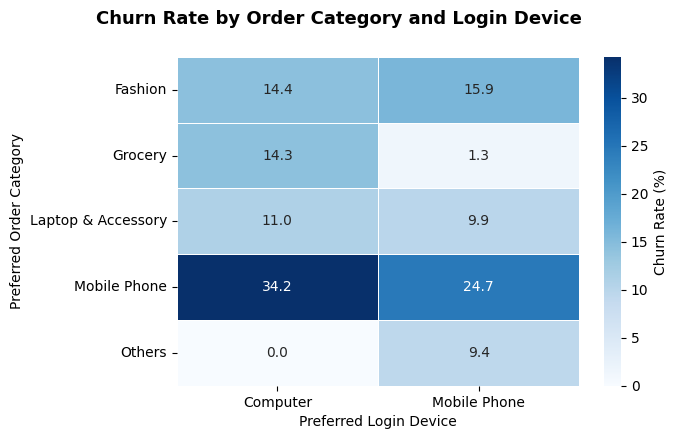

In [33]:
# Grouped heatmap for churn rate by preferred order category and login device

order_device_churn_heatmap = df_churn.pivot_table(values="Churn",index="PreferedOrderCat",columns="PreferredLoginDevice",aggfunc="mean") * 100

plt.figure(figsize=(7, 4.5))

ax = sns.heatmap(order_device_churn_heatmap,annot=True,fmt=".1f",cmap="Blues",linewidths=0.5,cbar_kws={"label": "Churn Rate (%)"})

ax.set_title("Churn Rate by Order Category and Login Device",loc="left",fontsize=13,fontweight="bold",pad=12, x=-0.2, y=1.05)
ax.set_xlabel("Preferred Login Device")
ax.set_ylabel("Preferred Order Category")

plt.tight_layout()
plt.show()

Churn rates also vary across preferred order categories and login devices. `Mobile Phone` order preference shows relatively high churn in both login-device groups, although small group sizes may make some combinations unstable.


### 3.4 Bubble Plot Analysis

The bubble plot compares tenure, cashback amount, and order count at the customer level.


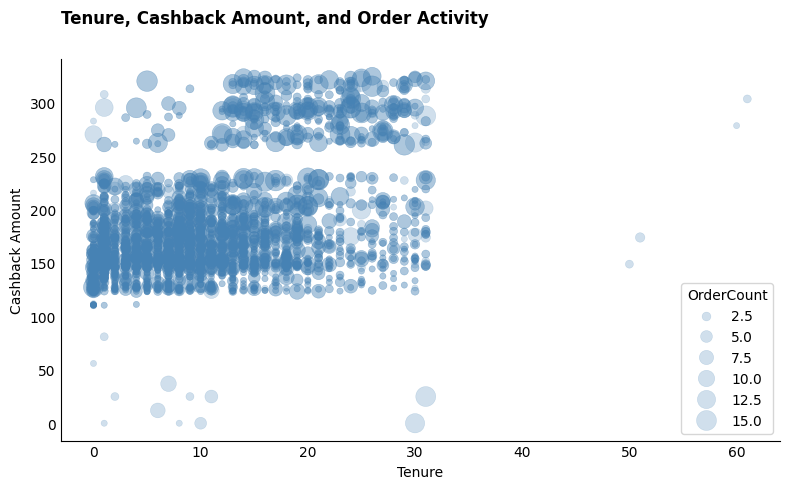

In [34]:
# Row-level bubble plot for Tenure, Cashback Amount, and Order Count

bubble_row_churn = df_churn[["Tenure", "CashbackAmount", "OrderCount"]].dropna().copy()

plt.figure(figsize=(8, 5))

ax = sns.scatterplot(data=bubble_row_churn,x="Tenure",y="CashbackAmount",size="OrderCount",sizes=(20, 220),
                     alpha=0.25,color="steelblue",edgecolor=None,legend="brief")

ax.set_title("Tenure, Cashback Amount, and Order Activity", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Tenure")
ax.set_ylabel("Cashback Amount")
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Tenure and cashback amount show a visible positive association, while order activity varies across the plot. A few observations sit far from the main cluster, particularly at very high tenure or unusually low cashback values.


### 3.5 Principal Component Analysis

PCA is applied to a temporary median-imputed, scaled copy of the numeric predictors. `Churn` is excluded from the PCA inputs and used only to interpret the resulting scores.


In [35]:
# Principal Component Analysis 

pca_data_churn = df_churn[pca_input_cols_churn].copy()
pca_data_churn_imputed = pca_data_churn.fillna(pca_data_churn.median())

scaler = StandardScaler()
pca_scaled_churn = scaler.fit_transform(pca_data_churn_imputed)

pca_churn = PCA()
pca_scores_churn = pca_churn.fit_transform(pca_scaled_churn)

explained_variance_churn = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca_input_cols_churn))],
    "Explained_Variance_Ratio": pca_churn.explained_variance_ratio_,
    "Cumulative_Explained_Variance": pca_churn.explained_variance_ratio_.cumsum()})

display(explained_variance_churn)

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.198696,0.198696
1,PC2,0.113409,0.312104
2,PC3,0.111487,0.423591
3,PC4,0.087615,0.511206
4,PC5,0.083978,0.595185
5,PC6,0.082694,0.677878
6,PC7,0.077343,0.755222
7,PC8,0.067754,0.822975
8,PC9,0.058483,0.881458
9,PC10,0.051070,0.932529


In [36]:
pca_loadings_churn = pd.DataFrame(
    pca_churn.components_.T,
    index=pca_input_cols_churn,
    columns=[f"PC{i+1}" for i in range(len(pca_input_cols_churn))])

display(pca_loadings_churn.round(3))
print("Top PC1 loadings:")
display(pca_loadings_churn[["PC1"]].sort_values("PC1", key=abs, ascending=False))

print("Top PC2 loadings:")
display(pca_loadings_churn[["PC2"]].sort_values("PC2", key=abs, ascending=False))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Tenure,0.308,-0.298,0.504,-0.148,0.037,-0.089,0.030,-0.104,-0.110,-0.384,-0.599,0.033
WarehouseToHome,0.016,0.173,-0.037,-0.256,0.809,-0.216,-0.410,0.141,-0.114,0.006,0.009,-0.002
HourSpendOnApp,0.206,0.595,0.055,0.081,-0.006,0.078,-0.073,-0.105,0.653,-0.368,-0.041,0.084
NumberOfDeviceRegistered,0.182,0.568,0.052,0.008,-0.200,0.140,-0.205,-0.367,-0.549,0.259,-0.190,0.023
SatisfactionScore,0.027,0.011,0.026,0.698,0.491,0.189,0.412,-0.193,-0.151,-0.070,-0.013,-0.003
NumberOfAddress,0.133,0.151,0.601,0.157,-0.004,0.070,0.043,0.564,0.107,0.485,0.025,0.046
Complain,-0.028,0.061,-0.025,-0.564,0.206,0.670,0.422,-0.003,0.029,0.068,-0.040,0.010
OrderAmountHikeFromlastYear,0.031,0.303,-0.007,-0.239,0.009,-0.641,0.655,-0.007,-0.080,0.043,0.036,-0.006
CouponUsed,0.461,0.071,-0.327,0.062,-0.072,0.082,0.042,0.432,-0.151,-0.183,-0.069,-0.640
OrderCount,0.500,-0.085,-0.326,0.024,-0.033,0.027,0.041,0.249,-0.136,-0.056,0.074,0.737


Top PC1 loadings:


,PC1
OrderCount,0.500123
CouponUsed,0.460623
CashbackAmount,0.436753
DaySinceLastOrder,0.394979
Tenure,0.308076
HourSpendOnApp,0.205848
NumberOfDeviceRegistered,0.182293
NumberOfAddress,0.132997
OrderAmountHikeFromlastYear,0.030970
Complain,-0.027989


Top PC2 loadings:


,PC2
HourSpendOnApp,0.595316
NumberOfDeviceRegistered,0.567586
OrderAmountHikeFromlastYear,0.302800
Tenure,-0.297856
DaySinceLastOrder,-0.229991
WarehouseToHome,0.172718
NumberOfAddress,0.150739
CashbackAmount,-0.146749
OrderCount,-0.085363
CouponUsed,0.070568


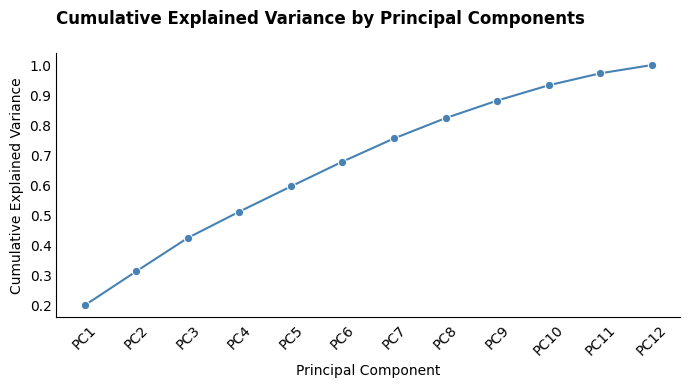

In [37]:
plt.figure(figsize=(7, 4))

ax = sns.lineplot(data=explained_variance_churn,x="Principal_Component",y="Cumulative_Explained_Variance",marker="o",color="steelblue")

ax.set_title("Cumulative Explained Variance by Principal Components", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.tick_params(axis="x", rotation=45, length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [38]:
pca_scores_df_churn = pd.DataFrame(pca_scores_churn[:, :2],columns=["PC1", "PC2"],index=df_churn.index)

pca_scores_df_churn["Churn"] = df_churn["Churn"]
pca_scores_df_churn["Churn_Label"] = (pca_scores_df_churn["Churn"].map({0: "No Churn", 1: "Churn"}))


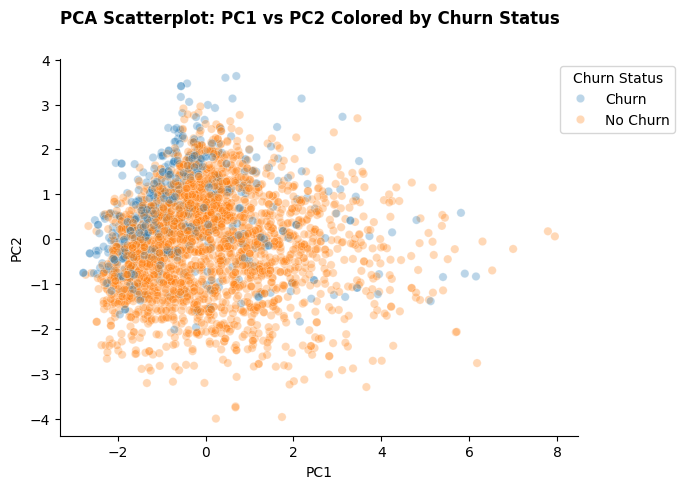

In [39]:
plt.figure(figsize=(7, 5))
pca_sample_churn = pca_scores_df_churn.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_sample_churn,x="PC1",y="PC2",hue="Churn_Label",alpha=0.3)

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Churn Status", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Churn Status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

PC1 explains about 19.9% of variance, while PC1 and PC2 together explain about 31.2%. Roughly nine components are needed to reach 88% cumulative variance, so the dataset does not compress well into one or two dimensions. The PCA scatterplot also shows substantial overlap between churned and non-churned customers.


### 3.6 Linear Regression Analysis

Regression is used only for continuous or count-like variables with stronger pairwise relationships. `Churn` is not modeled here because it is a binary classification target.


In [40]:
# Linear regression using the strongest correlated numeric variables

variables_churn = [ "CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Tenure"]

regression_data_churn = df_churn[variables_churn].copy()
regression_data_churn = regression_data_churn.fillna(regression_data_churn.median())

results_churn = []

for target in variables_churn:
    
    predictors = [col for col in variables_churn if col != target]
    
    X = regression_data_churn[predictors]
    y = regression_data_churn[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_churn.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse})

regression_results_churn = pd.DataFrame(results_churn)
regression_results_churn

,target,predictors,test_r2_score,test_mse
0,CouponUsed,"[OrderCount, DaySinceLastOrder, CashbackAmount...",0.372836,2.183161
1,OrderCount,"[CouponUsed, DaySinceLastOrder, CashbackAmount...",0.451235,4.473137
2,DaySinceLastOrder,"[CouponUsed, OrderCount, CashbackAmount, Tenure]",0.195694,10.692776
3,CashbackAmount,"[CouponUsed, OrderCount, DaySinceLastOrder, Te...",0.273334,1783.052337
4,Tenure,"[CouponUsed, OrderCount, DaySinceLastOrder, Ca...",0.187114,53.747064


`OrderCount` is the most predictable target in this group with a test R² of about 0.45, followed by `CouponUsed` at about 0.37. The remaining targets have weaker linear relationships. These results support the correlation findings but should be interpreted as association rather than causation.


### 3.7 Dataset 3 Summary

Dataset 3 provides the most directly useful churn-related multivariate structure. `Tenure` has the strongest numeric association with churn (about −0.35), while `Complain` has a positive association (about 0.25). Grouped heatmaps reinforce the importance of complaint status.

PCA does not create clear churn separation and requires several components to retain most variance, so dimensionality reduction alone is unlikely to solve the churn problem. The dataset remains well suited to later classification modeling, with missingness and class imbalance handled explicitly in that workflow.


## 4. Purchase Experience

This section examines multivariate relationships among order value, product category, customer engagement, delivery, and satisfaction.


### 4.1 Data Setup


In [41]:
df_purchase_experience = pd.read_pickle(DATA_DIR / "df_purchase_experience_eda.pkl")
df_purchase_experience.shape


(5000, 18)

### 4.2 Variable Selection

`Total_Amount` is treated as an order-value outcome and `Customer_Rating` as a customer-experience outcome. Identifier columns are excluded from multivariate modeling.


In [42]:
numeric_cols_purchase = ["Age", "Unit_Price", "Quantity", "Discount_Amount","Total_Amount", "Session_Duration_Minutes","Pages_Viewed", "Delivery_Time_Days", "Customer_Rating"]

categorical_cols_purchase = ["Gender", "City", "Product_Category","Payment_Method", "Device_Type","Is_Returning_Customer"]

identifier_cols_purchase = ["Order_ID", "Customer_ID"]
date_col_purchase = "Date"
target_like_cols_purchase = ["Total_Amount", "Customer_Rating","Is_Returning_Customer"]


### 4.3 Correlation and Grouped Heatmaps

Correlation and grouped heatmaps are used to compare order value, product mix, device behavior, payment method, and customer rating.


In [43]:
corr_purchase = df_purchase_experience[numeric_cols_purchase].corr()


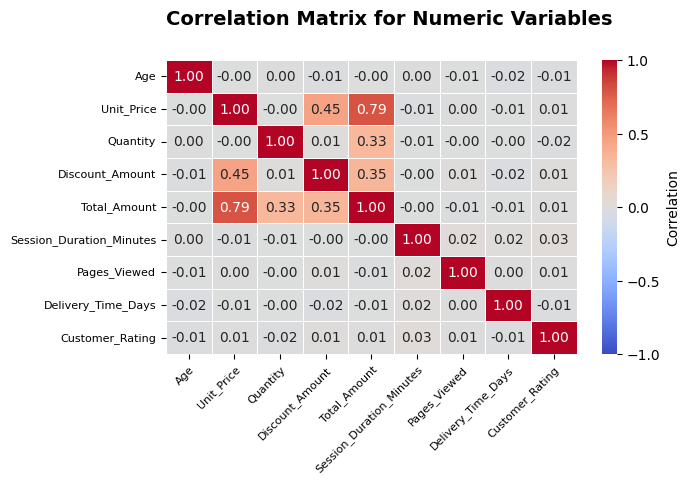

In [44]:
# Heatmap of correlations
plt.figure(figsize=(7, 5))

ax = sns.heatmap(corr_purchase ,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

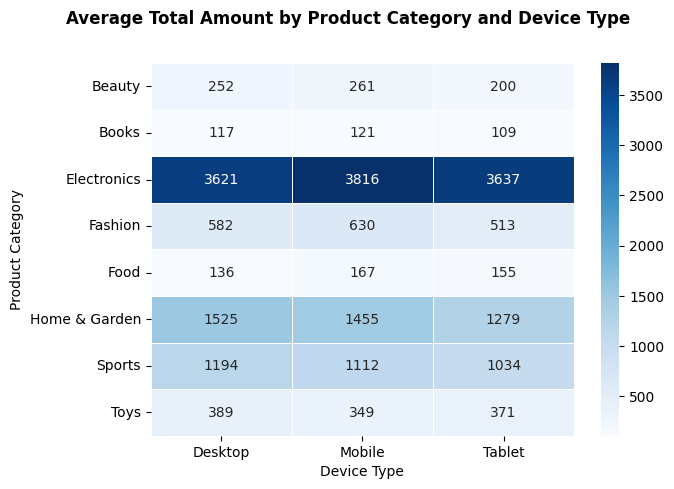

In [45]:
avg_amount_heatmap = (df_purchase_experience.pivot_table(values="Total_Amount",index="Product_Category",columns="Device_Type",aggfunc="mean" ))

plt.figure(figsize=(7, 5))

sns.heatmap(avg_amount_heatmap,annot=True,cmap="Blues",fmt=".0f",linewidths=0.5)

plt.title("Average Total Amount by Product Category and Device Type", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.2, y=1.05)
plt.xlabel("Device Type")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Electronics has the highest average order value across device types, with Home & Garden and Sports also relatively high. Because product categories naturally differ in price, raw order-value differences should not be interpreted as device effects.


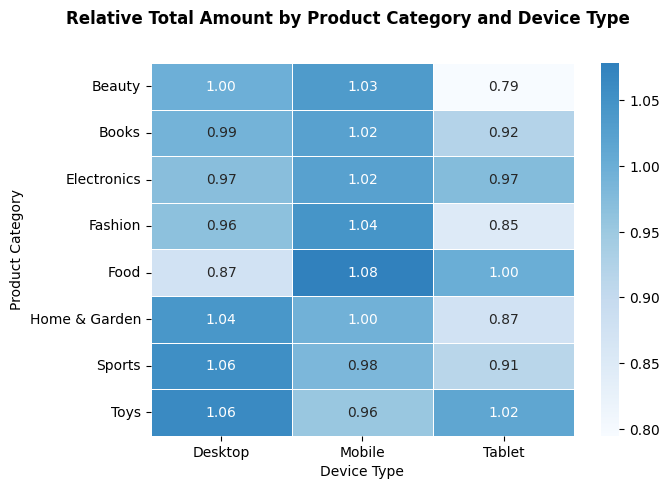

In [46]:
plot_df = df_purchase_experience.copy()

category_avg_amount = plot_df.groupby("Product_Category")["Total_Amount"].transform("mean")

plot_df["Relative_Total_Amount"] = plot_df["Total_Amount"] / category_avg_amount

relative_amount_heatmap = (plot_df.pivot_table(values="Relative_Total_Amount",index="Product_Category",
                                               columns="Device_Type",aggfunc="mean"))
plt.figure(figsize=(7, 5))

sns.heatmap(relative_amount_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5,center=1)

plt.title("Relative Total Amount by Product Category and Device Type", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.2, y=1.05)
plt.xlabel("Device Type")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

After normalizing each transaction by its product-category average, most device-level values are close to 1. This indicates that device type contributes relatively little additional variation in order value within product categories.


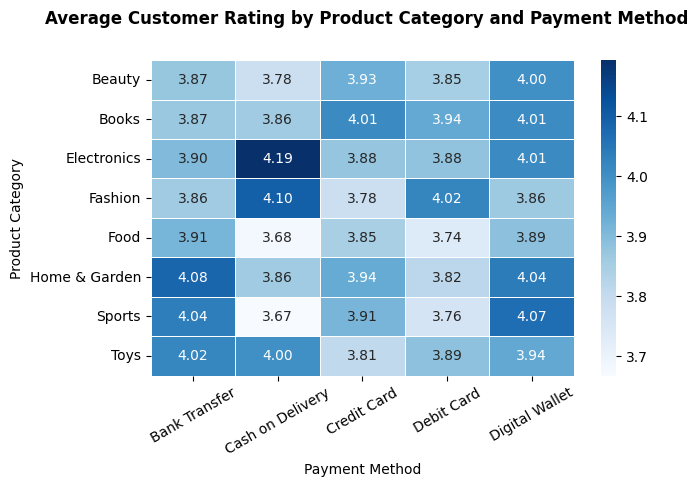

In [47]:
avg_rating_heatmap = (df_purchase_experience.pivot_table(values="Customer_Rating",index="Product_Category",columns="Payment_Method",aggfunc="mean"))

plt.figure(figsize=(7, 5))

sns.heatmap(avg_rating_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5)

plt.title("Average Customer Rating by Product Category and Payment Method", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.25, y=1.05)
plt.xlabel("Payment Method")
plt.xticks(rotation=30)
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Average customer ratings are tightly grouped across product-category and payment-method combinations, generally around 3.7–4.2. The small differences do not suggest a strong multivariate satisfaction pattern.


### 4.4 Bubble Plot Analysis

The bubble plot compares average session duration, average order value, and average pages viewed across product categories.


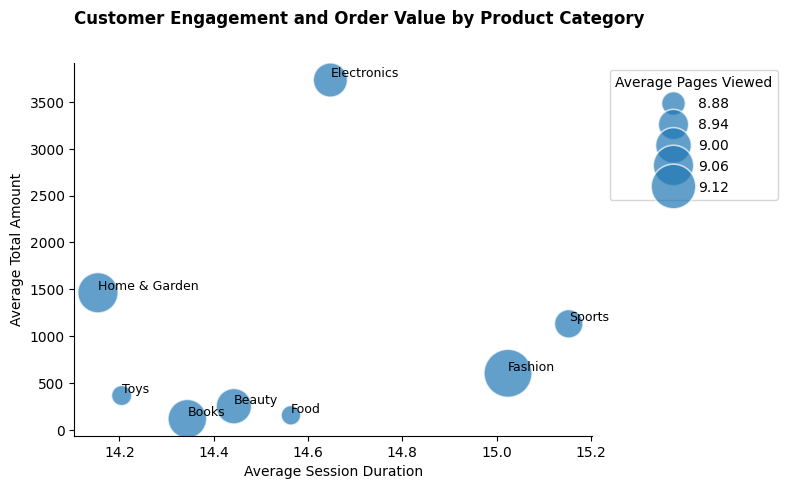

In [48]:
bubble_purchase = (df_purchase_experience.groupby("Product_Category").agg(
    avg_session_duration=("Session_Duration_Minutes", "mean"),
    avg_total_amount=("Total_Amount", "mean"),
    avg_pages_viewed=("Pages_Viewed", "mean")).reset_index())

plt.figure(figsize=(8, 5))

ax = sns.scatterplot(data=bubble_purchase,x="avg_session_duration",y="avg_total_amount",size="avg_pages_viewed",sizes=(200, 1200),alpha=0.7,legend="brief")

for i, row in bubble_purchase.iterrows():
    plt.text(row["avg_session_duration"],row["avg_total_amount"],row["Product_Category"],fontsize=9,ha="left",va="bottom")

plt.title("Customer Engagement and Order Value by Product Category", loc="left", fontsize=12, y=1.05, fontweight="bold", pad=15)
plt.xlabel("Average Session Duration")
plt.ylabel("Average Total Amount")
plt.legend(title="Average Pages Viewed", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Electronics has the highest average order value, but longer sessions or more pages viewed do not consistently correspond to higher order value. Product category appears more strongly associated with order value than these engagement measures.


### 4.5 Principal Component Analysis

PCA is applied to scaled numeric predictors. `Total_Amount` and `Customer_Rating` are excluded from the PCA inputs so they can be used for interpretation rather than defining the components.


In [49]:
pca_features_purchase = ["Age","Unit_Price","Quantity","Discount_Amount","Session_Duration_Minutes","Pages_Viewed","Delivery_Time_Days"]

pca_data_purchase = df_purchase_experience[pca_features_purchase].copy()

scaler_purchase = StandardScaler()
pca_scaled_purchase = scaler_purchase.fit_transform(pca_data_purchase)

pca_purchase = PCA()
pca_scores_purchase = pca_purchase.fit_transform(pca_scaled_purchase)

explained_variance_purchase = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca_features_purchase))],
    "Explained_Variance_Ratio": pca_purchase.explained_variance_ratio_,
    "Cumulative_Explained_Variance": pca_purchase.explained_variance_ratio_.cumsum()
})

explained_variance_purchase

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.207310,0.207310
1,PC2,0.147779,0.355089
2,PC3,0.144284,0.499373
3,PC4,0.142629,0.642002
4,PC5,0.141216,0.783218
5,PC6,0.138296,0.921513
6,PC7,0.078487,1.000000


In [50]:
pca_loadings_purchase = pd.DataFrame(
    pca_purchase.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_features_purchase))],
    index=pca_features_purchase
)
pca_loadings_purchase.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Age,-0.020,-0.302,0.687,-0.094,0.530,-0.383,0.017
Unit_Price,0.705,0.012,-0.005,-0.042,0.043,-0.018,-0.706
Quantity,0.017,-0.238,-0.150,0.936,0.210,-0.020,-0.029
Discount_Amount,0.707,0.011,-0.001,0.007,0.023,0.013,0.707
Session_Duration_Minutes,-0.019,0.595,0.352,0.142,0.351,0.615,-0.014
Pages_Viewed,0.021,0.532,0.364,0.291,-0.487,-0.513,-0.006
Delivery_Time_Days,-0.040,0.464,-0.499,-0.096,0.559,-0.461,0.022


PC1 explains about 20.7% of variance and is dominated by `Unit_Price` and `Discount_Amount`. PC2 explains about 14.8% and is more strongly associated with session duration, pages viewed, and delivery time. Together, the first two components explain about 35.5%, so the dataset does not reduce strongly to two dimensions.


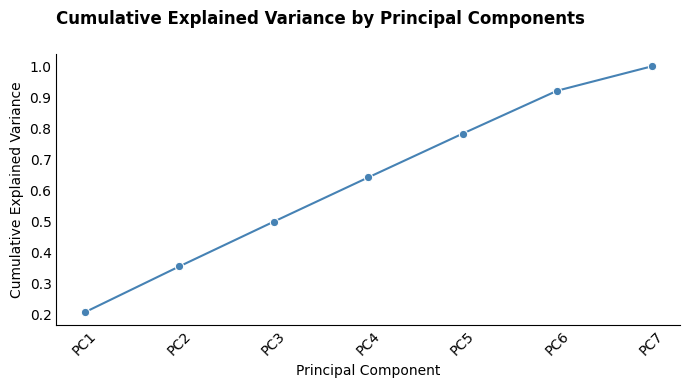

In [51]:
plt.figure(figsize=(7, 4))

ax = sns.lineplot(data=explained_variance_purchase,x="Principal_Component",y="Cumulative_Explained_Variance",marker="o",color="steelblue")

ax.set_title("Cumulative Explained Variance by Principal Components", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.tick_params(axis="x", rotation=45, length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [52]:
pca_scores_df_purchase = pd.DataFrame(pca_scores_purchase[:, :2],columns=["PC1", "PC2"],index=df_purchase_experience.index)

pca_scores_df_purchase["total_amount"] = df_purchase_experience["Total_Amount"]
pca_scores_df_purchase["Customer_Rating"] = df_purchase_experience["Customer_Rating"]
pca_scores_df_purchase["product_category"] = df_purchase_experience["Product_Category"]


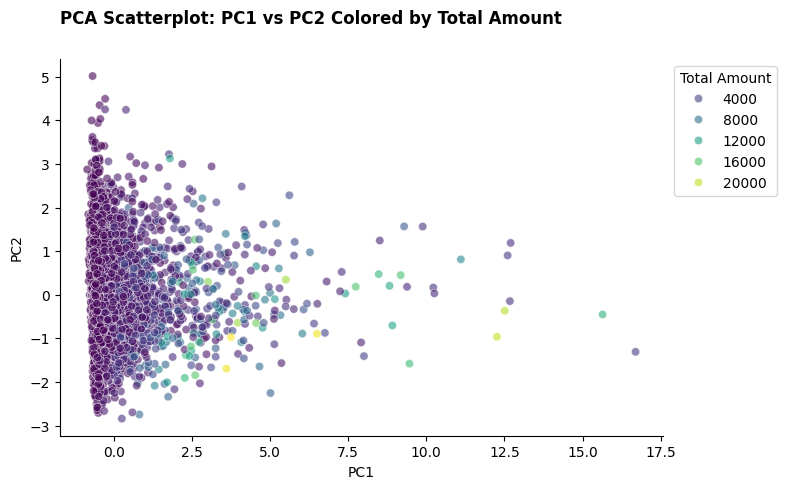

In [53]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="total_amount",alpha=0.6, palette="viridis")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Total Amount", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Total Amount", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

Higher-value orders appear more often on the positive side of PC1, which is consistent with PC1's strong price and discount loadings. The first two components still do not cleanly separate low- and high-value orders.


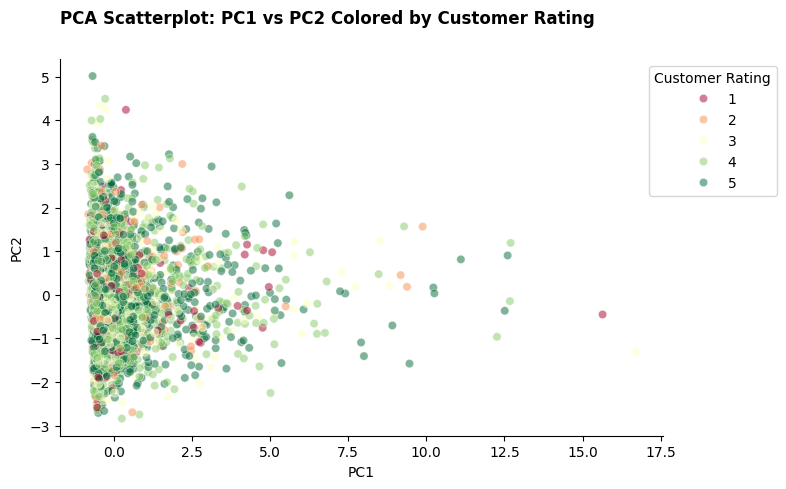

In [54]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="Customer_Rating",alpha=0.5, palette = "RdYlGn")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Customer Rating", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Customer Rating", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

Customer-rating levels overlap heavily in the PCA space, indicating that the first two components do not meaningfully separate satisfaction outcomes.


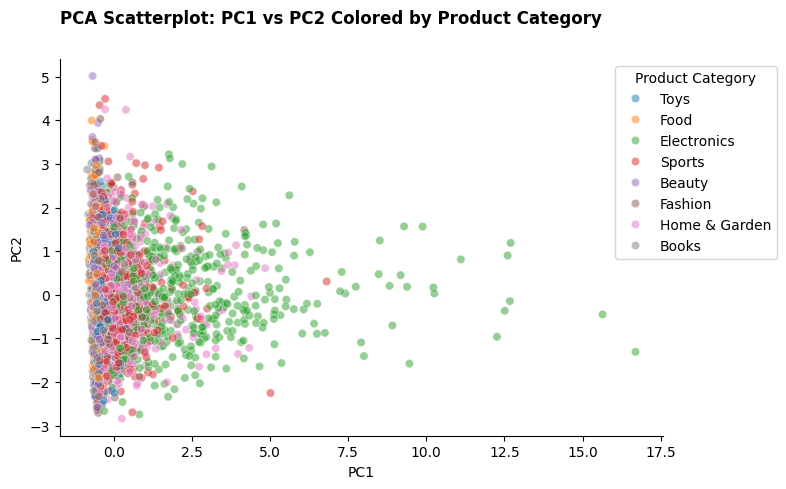

In [55]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="product_category",alpha=0.5, palette="tab10")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Product Category", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Product Category", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

Electronics appears more often on the positive side of PC1, consistent with its higher price-related values. Most other categories overlap substantially, so PCA does not produce distinct product clusters.


### 4.6 Linear Regression Analysis

Simple linear regression is used to quantify relationships among price, quantity, discount, and total order amount.


In [56]:
# Linear regression using the strongest correlated numeric variables

variables_purchase = ["Unit_Price","Quantity","Discount_Amount","Total_Amount"]

regression_data_purchase = df_purchase_experience[variables_purchase].copy()

results_purchase = []

for target in variables_purchase:
    
    predictors = [col for col in variables_purchase if col != target]
    
    X = regression_data_purchase[predictors]
    y = regression_data_purchase[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_purchase.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse})

regression_results_purchase = pd.DataFrame(results_purchase)

regression_results_purchase

,target,predictors,test_r2_score,test_mse
0,Unit_Price,"[Quantity, Discount_Amount, Total_Amount]",0.744812,97714.109874
1,Quantity,"[Unit_Price, Discount_Amount, Total_Amount]",0.280452,1.275602
2,Discount_Amount,"[Unit_Price, Quantity, Total_Amount]",0.155414,3533.299534
3,Total_Amount,"[Unit_Price, Quantity, Discount_Amount]",0.741009,564531.402661


`Unit_Price` and `Total_Amount` each achieve test R² values around 0.74, while `Quantity` and `Discount_Amount` are much less predictable. These high scores should be interpreted cautiously because `Total_Amount` is directly constructed from price, quantity, and discount information; the models therefore capture a structural transaction relationship rather than a broad behavioral signal.


### 4.7 Dataset 4 Summary

Dataset 4 contains useful structure around purchase value and product category. Price-related variables dominate the strongest correlations and the first PCA direction, while customer rating and engagement variables show much weaker relationships.

The first two principal components explain only about 35.5% of total variance. The strongest regression results are driven by the direct relationship between order amount and its price/quantity/discount components, so those variables should be excluded when building a leakage-aware model intended to predict `Total_Amount` from pre-purchase information.


## Cross-Dataset Takeaways

- **User Behavior & Engagement:** clear financial redundancy and some engagement structure, but purchase intent is not cleanly separated by the first two principal components.
- **Sales & Customer Insights:** technically clean but shows very weak correlation, PCA, and regression signal; it is deprioritized for downstream modeling.
- **Customer Churn:** provides the strongest interpretable churn-related relationships, especially for tenure and complaint status, although PCA does not separate churn classes well.
- **Purchase Experience:** contains strong order-value structure, but the strongest relationships are partly mechanical because total amount is directly connected to price, quantity, and discount.

Overall, the multivariate analysis supports using the churn dataset as the strongest source for retention modeling, while the other datasets provide complementary evidence about engagement and customer value.
